# 아이돌보미 관련 맘카페 게시글 감정분석

In [2]:
import pandas as pd
import pymongo
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='NanumBarunGothic') # 혹은 다른 설치한 Nanum 폰트 사용
import scipy
import scipy.stats as stats
from konlpy.tag import Okt
okt = Okt()
from mecab import MeCab
mecab = MeCab()

# 데이터 로드 

## 게시글 데이터 로드

In [3]:
baby_care_contents = pd.read_json('../../dataset/baby_care_naver_cafe/baby_care_contents.json')
baby_care_contents.drop('_id',axis=1,inplace=True)
# baby_care_contents['contents']

In [4]:
baby_care_reviews = pd.read_json('../../dataset/baby_care_naver_cafe/baby_care_reaction.json')
baby_care_reviews.drop('_id',axis=1,inplace=True)
# baby_care_reviews['review']

# 데이터 전처리

## 중복값 제거

In [5]:
baby_care_contents.drop_duplicates(keep='first',inplace=True)
baby_care_contents.reset_index(inplace=True)
baby_care_contents.drop('index',axis=1,inplace=True)
baby_care_contents

,title,date,contents,like
0,아이돌보미(시터) 선생님 스타일이 너무 안맞으면 어떻게 하시나요?,2024-08-07 11:10:00,나이가 좀 많으세요\n저희 친정 시댁 어른들보다도 6살 더 많으심....\n그래서 ...,0
1,남편이랑 싸운 다음날 육아,2024-08-07 09:41:00,어제 남편하고 싸우고 나니까\n아침에 애기는 너무 귀여운데 육아하기 싫고\n잠깐 어...,1
2,맘님이 애가 어리고 복직을 꼭 해야하는 상황,2024-08-06 13:06:00,저는 어렸을때부터 애기를 너무 좋아했고 처녀때 조카들도 다 키웠다 할만큼 맨날 놀러...,0
3,필리핀 가사도우미? 신청하신 분 있으세요?,2024-08-06 10:30:00,서울시에서 신청받고있는 필리핀 가사도우미? 가사관리사?\n정확하게말하면 도우미 관리...,0
4,아이돌보미 서비스 신청 결제 관련해서 여쭤봅니다,2024-08-04 12:29:00,"안녕하세요.\n여행 다녀와서 애기, 저, 친정엄마 세명 다 코로나 확진\n판정 받고...",0
...,...,...,...,...
2042,정부지원 아이돌보미 서비스...황당해요,2017-10-25 17:39:00,"★ 잠깐! 게시글 작성 전, 필독 공지! ★\n- 카페규정 : http://cafe...",2
2043,아이돌보미 시간제보육ㅠ,2017-10-25 02:48:00,1월에 회사에 복직해요~ 계속 일할건 아니고\n두달정도만 나가면 될것같아요.\n...,0
2044,정부지원 아이돌보미 서비스...황당해요,2017-10-25 17:39:00,"★ 잠깐! 게시글 작성 전, 필독 공지! ★\n- 카페규정 : http://cafe...",0
2045,아이돌봄서비스 이용하시는분들께 질문드려요~,2017-11-29 23:43:00,곧 출근 앞두고 있는데요..\n아이돌봄서비스 처음 이용해봐요~~\n6세 3세 형제예...,0


## 줄바꿈 제거

In [7]:
baby_care_contents['contents'] = baby_care_contents['contents'].str.replace('\n',' ')
baby_care_contents['contents'] = baby_care_contents['contents'].str.replace('★ 잠깐! 게시글 작성 전, 필독 공지! ★ - 카페규정 : http://cafe.naver.com/imsanbu/28123090  - 게시판별 운영 정책 : http://cafe.naver.com/imsanbu/35756864',' ')
baby_care_reviews['review'] = baby_care_reviews['review'].str.replace('\n',' ')

## 게시글, 댓글 데이터 병합

In [101]:
momcafe_contents = baby_care_contents[['contents']]

## 형태소 분리

In [102]:
from konlpy.tag import Okt
okt = Okt()
def Tokenizer(raw):
    word_list = []
    for word, tag in okt.pos(raw,norm=True,stem=True):
        word_list.append(word)
    return " ".join(word_list)

In [2]:
momcafe_contents['contents'] = momcafe_contents['contents'].astype(str)

In [1]:
momcafe_contents['contents_clean'] = momcafe_contents['contents'].apply(Tokenizer)
# momcafe_contents

# 긍정 게시글 토픽 분류

In [418]:
stopwords = ['오늘','내년','아시','일제','답변','해당','베이비','산후','선생님','서비스','보미','아이','아기','신분','가요','대요','도우미','계속','정도','이모','지금','얘기','동의','애기','애가','아가','시간','사람','생각','부분','보통','본인','경우','말씀','조금','얼마','요즘',]
# stopwords = []
def Tokenizer_noun(raw, pos=["Noun"], stopword=stopwords):
    word_list = []
    for word, tag in okt.pos(raw,norm=True,stem=True):
        if len(word) > 1 and tag in pos and word not in stopword:
            if mecab.pos(word)[0][1] in ["NNG"]:
                word_list.append(word)
    return " ".join(word_list)

In [419]:
def noun_set(raw):
    noun_list = list(set(raw.split(' ')))
    return " ".join(noun_list)

In [420]:
momcafe_contents['noun_list'] = momcafe_contents['contents'].apply(Tokenizer_noun)

In [421]:
momcafe_contents['noun_set'] = momcafe_contents['noun_list'].apply(noun_set)

In [422]:
momcafe_contents = momcafe_contents.query("noun_list !=''")
momcafe_contents = momcafe_contents.reset_index()

In [423]:
momcafe_contents.drop('index',axis=1,inplace=True)
# momcafe_contents

In [424]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfVectorizer_topic = TfidfVectorizer(use_idf=True,max_df=0.8,min_df=0.02)
features = tfidfVectorizer_topic.fit_transform(momcafe_contents['noun_list'])
features.toarray()[:2]
dictionary_list = tfidfVectorizer_topic.get_feature_names_out()


In [425]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model = LatentDirichletAllocation(n_components=4, random_state=36) #인스턴스화 #n_components 토픽의 갯수
lda_model.fit(features)
import pandas as pd
pd.set_option('display.max_colwidth', None)
## 상위 단어 추출 
## 0 확률 1은 dictionary
topics_list = list()
for topic in lda_model.components_:
    df_datas = [topic, dictionary_list]
    df_topics = pd.DataFrame(data=df_datas)
    df_topics= df_topics.T
    df_topics = df_topics.sort_values(0, ascending=False)
    # print(df_topics[:3])
    topics_text = ' '.join(df_topics[1].values[:20])# 시리즈 형식으로 출력 get values from series / index 
    topics_list.append(topics_text)
topics_list_add = [['Topic1', 'Topic2','Topic3','Topic4'],topics_list]
df_topics_keywords = pd.DataFrame(topics_list_add)
df_topics_keywords=df_topics_keywords.T
df_topics_keywords



,0,1
0,Topic1,남편 엄마 육아 친정 어린이집 걱정 출산 도움 신랑 혼자 회사 시댁 상황 직장 복직 출근 고민 조리 친정엄마 부모님
1,Topic2,어린이집 하원 이용 등원 복직 보육 오후 가정 신청 하루 시간제 고민 연장 연락 예정 적응 오전 근무 종일 대기
2,Topic3,신청 지원 정부 이용 센터 대기 맞벌이 소득 배정 업체 정보 부담 금액 지역 면접 개인 기준 사설 건강 나라
3,Topic4,목욕 추천 처음 쌍둥이 청원 아침 영상 엄마 먹이 분유 저녁 청소 낮잠 설치 티비 케어 둥이 식사 젖병 혼자


In [426]:
list_topics = []
for i in range(len(lda_model.components_)):
    df_datas = [lda_model.components_[i], dictionary_list]
    df_topics = pd.DataFrame(data=df_datas).T
    df_topics = df_topics.dropna()
    df_topics = df_topics.sort_values(0, ascending=False).reset_index()
    df_topics.rename(columns = {1 : i+1}, inplace = True)
    df_topics.rename(columns = {0 : 'score'}, inplace = True)
    list_topics.append(df_topics.loc[:4,['score',i+1]])
df_topic = pd.concat(list_topics,axis=1)
df_topic


,score,1,score,2,score,3,score,4
0,60.589999,남편,87.86089,어린이집,119.774201,신청,27.017088,목욕
1,47.327302,엄마,60.960407,하원,96.624325,지원,23.497045,추천
2,47.019567,육아,36.512046,이용,90.261903,정부,22.784338,처음
3,45.794641,친정,31.282598,등원,76.049913,이용,22.734757,쌍둥이
4,38.017676,어린이집,31.212218,복직,30.431237,센터,22.675451,청원


In [427]:
import pyLDAvis
import pyLDAvis.lda_model
vis = pyLDAvis.lda_model.prepare(lda_model,features,tfidfVectorizer_topic)
vis
pyLDAvis.enable_notebook()
components_display = pyLDAvis.display(vis)
components_display

In [428]:
topics_list = list()
for topic in lda_model.components_:
    df_datas = [topic, dictionary_list]
    df_topics = pd.DataFrame(data=df_datas)
    df_topics= df_topics.T
    df_topics = df_topics.sort_values(0, ascending=False)

In [429]:
topics_output = lda_model.transform(features)
df_topics_score = pd.DataFrame(topics_output)
df_topics_score['dominant_topic_number']=np.argmax(topics_output, axis=1)
df_topics_score['dominant_topic_number'].value_counts()

dominant_topic_number
0    690
2    513
1    427
3    396
Name: count, dtype: int64

In [430]:
momcafe_contents.loc[:,'content_topic'] = df_topics_score['dominant_topic_number']
# momcafe_contents

In [431]:
momcafe_contents_text_0 = ' '.join(momcafe_contents.loc[momcafe_contents['content_topic']==0]['noun_list'])
momcafe_contents_text_1 = ' '.join(momcafe_contents.loc[momcafe_contents['content_topic']==1]['noun_list'])
momcafe_contents_text_2 = ' '.join(momcafe_contents.loc[momcafe_contents['content_topic']==2]['noun_list'])
momcafe_contents_text_3 = ' '.join(momcafe_contents.loc[momcafe_contents['content_topic']==3]['noun_list'])

In [432]:
# pip install wordcloud

In [433]:
from wordcloud import WordCloud


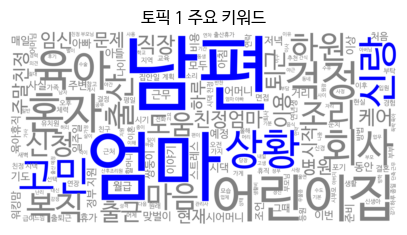

In [478]:
highlighted_words = ["남편","신랑","엄마","고민",'상황']
def custom_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    if word in highlighted_words:
        return "blue"  # 특정 단어 색상
    else:
        return "gray"   # 나머지 단어 색상
        
from wordcloud import WordCloud
wordCloud = WordCloud(scale=10, color_func=custom_color_func, background_color="white", font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf').generate_from_text(momcafe_contents_text_0)
wordCloud.words_
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 10))
plt.imshow(wordCloud,interpolation='bilinear')
plt.title('토픽 1 주요 키워드')
plt.axis('off')
plt.show()

In [3]:
# momcafe_contents.loc[(momcafe_contents['content_topic']==0)&(momcafe_contents['contents'].str.contains('엄마'))][20:]
# momcafe_contents.loc[(momcafe_contents['content_topic']==1)]

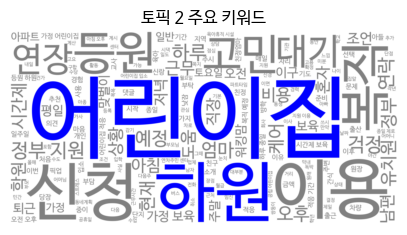

In [474]:
highlighted_words = ['하원','어린이집']

def custom_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    if word in highlighted_words:
        return "blue"  # 특정 단어 색상
    else:
        return "gray"   # 나머지 단어 색상
        
from wordcloud import WordCloud
wordCloud = WordCloud(scale=10, color_func=custom_color_func, background_color="white", font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf').generate_from_text(momcafe_contents_text_1)
wordCloud.words_
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 10))
plt.imshow(wordCloud,interpolation='bilinear')
plt.title('토픽 2 주요 키워드')
plt.axis('off')
plt.show()

In [452]:
# momcafe_contents.loc[(momcafe_contents['content_topic']==1)&(momcafe_contents['contents'].str.contains('하원'))]
momcafe_contents.loc[(momcafe_contents['content_topic']==1)&(momcafe_contents['contents'].str.contains('하원'))]

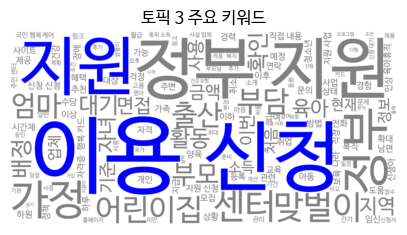

In [475]:
highlighted_words = ["신청",'이용','지원']

def custom_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    if word in highlighted_words:
        return "blue"  # 특정 단어 색상
    else:
        return "gray"   # 나머지 단어 색상
        
from wordcloud import WordCloud
wordCloud = WordCloud(scale=10, color_func=custom_color_func, background_color="white", font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf').generate_from_text(momcafe_contents_text_2)
wordCloud.words_
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 10))
plt.imshow(wordCloud,interpolation='bilinear')
plt.title('토픽 3 주요 키워드')
plt.axis('off')
plt.show()

In [469]:
# momcafe_contents.loc[(momcafe_contents['content_topic']==2)&(momcafe_contents['contents'].str.contains('신청'))][30:]

In [466]:
momcafe_contents_text_3 = momcafe_contents_text_3.replace('엄마','')
momcafe_contents_text_3 = momcafe_contents_text_3.replace('이용','')
momcafe_contents_text_3 = momcafe_contents_text_3.replace('신청','')

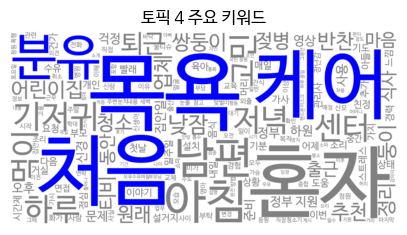

In [476]:
highlighted_words = ["목욕","케어","처음","분유"]

def custom_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    if word in highlighted_words:
        return "blue"  # 특정 단어 색상
    else:
        return "gray"   # 나머지 단어 색상
        
from wordcloud import WordCloud
wordCloud = WordCloud(scale=10, color_func=custom_color_func, background_color="white", font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf').generate_from_text(momcafe_contents_text_3)
wordCloud.words_
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 10))
plt.imshow(wordCloud,interpolation='bilinear')
plt.title('토픽 4 주요 키워드')
plt.axis('off')
plt.show()

In [4]:
# momcafe_contents.loc[(momcafe_contents['content_topic']==3)&(momcafe_contents['contents'].str.contains('처음'))]